# Notebook 06 - MLflow Experiment Tracking

## Objective

In previous notebooks, we trained and evaluated multiple machine learning and deep learning models for retail demand forecasting.

As the number of experiments grows, manually tracking model configurations, metrics, and artifacts becomes difficult.

This notebook introduces MLflow for:

- Experiment Tracking
- Parameter Logging
- Metric Logging
- Artifact Management
- Model Registry

The goal is to create a reproducible experiment management workflow for the Retail Demand Intelligence Platform.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import mlflow
import mlflow.sklearn

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print("MLflow Version:", mlflow.__version__)

MLflow Version: 3.14.0


In [3]:
mlflow.set_experiment("Rossmann_Demand_Forecasting")

<Experiment: artifact_location='file:///r:/Demand_Intelligence_Engine/notebooks/mlruns/1', creation_time=1782215951986, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1782215951986, lifecycle_stage='active', name='Rossmann_Demand_Forecasting', tags={}, trace_location=None, workspace='default'>

In [4]:
df = pd.read_csv(
    "../data/processed/model_ready_data.csv"
)

print(df.shape)
df.head()

(985989, 42)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2,...,StateHoliday_c,Sales_Lag_7,Sales_Lag_14,Sales_Lag_28,Sales_RollingMean_7,Sales_RollingMean_14,Sales_RollingMean_28,Sales_RollingStd_7,Sales_RollingStd_14,Sales_RollingStd_28
0,1,2,2013-01-29,3725,522,1,0,0,1270.0,0,...,0,5720.0,3900.0,0.0,4533.142857,4170.500000,4121.285714,2080.017823,1899.595898,2075.631146
1,1,3,2013-01-30,4601,560,1,0,0,1270.0,0,...,0,5578.0,4008.0,5530.0,4248.142857,4158.000000,4254.321429,2026.274696,1902.086951,1914.845455
2,1,4,2013-01-31,4709,571,1,0,0,1270.0,0,...,0,5195.0,4044.0,4327.0,4108.571429,4200.357143,4221.142857,1951.681400,1905.090008,1899.913267
3,1,5,2013-02-01,5633,658,1,0,0,1270.0,0,...,0,5586.0,4127.0,4486.0,4039.142857,4247.857143,4234.785714,1914.889329,1909.177546,1902.071860
4,1,6,2013-02-02,5970,701,1,0,0,1270.0,0,...,0,5598.0,5182.0,4997.0,4045.857143,4355.428571,4275.750000,1921.288841,1943.954681,1919.949818


In [5]:
df["Date"] = pd.to_datetime(df["Date"])

train_df = df[df["Date"] <= "2015-05-31"]
valid_df = df[df["Date"] >= "2015-06-01"]

In [6]:
print(train_df.shape)
print(valid_df.shape)

(917974, 42)
(68015, 42)


In [7]:
target = "Sales"

drop_cols = ["Sales","Customers", "Date"]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df[target]

X_valid = valid_df.drop(columns=drop_cols)
y_valid = valid_df[target]

In [8]:
from xgboost import XGBRegressor

with mlflow.start_run(run_name="XGBoost_All_Stores"):
    
    model = XGBRegressor(
        n_estimators=300,
        max_depth=8,
        learning_rate=0.05,
        random_state=42
    )

    model.fit(X_train, y_train)

    preds = model.predict(X_valid)

In [9]:
mae = mean_absolute_error(y_valid, preds)

rmse = np.sqrt(
    mean_squared_error(y_valid, preds)
)

r2 = r2_score(y_valid, preds)

print(mae, rmse, r2)

547.5856323242188 826.3662550588571 0.9527417421340942


In [10]:
mlflow.log_param("n_estimators", 300)
mlflow.log_param("max_depth", 8)
mlflow.log_param("learning_rate", 0.05)

0.05

In [11]:
mlflow.log_metric("mae", mae)
mlflow.log_metric("rmse", rmse)
mlflow.log_metric("r2", r2)

In [12]:
mlflow.set_tag(
    "dataset_type",
    "all_stores"
)

mlflow.set_tag(
    "model_family",
    "xgboost"
)

mlflow.set_tag(
    "business_use_case",
    "sales_forecasting"
)

In [13]:
import mlflow.xgboost

In [14]:

mlflow.xgboost.log_model(
    model,
    artifact_path="xgboost_model"
)

2026/06/25 10:24:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


In [15]:
import mlflow

print("Active Run:", mlflow.active_run())

Active Run: <ActiveRun: >


In [16]:
mlflow.end_run()
print(mlflow.active_run())

None


In [17]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

for exp in client.search_experiments():
    print(exp.name)

Rossmann_Demand_Forecasting
Default


In [18]:
import os
import mlflow

print(os.getcwd())
print(mlflow.get_tracking_uri())

r:\Demand_Intelligence_Engine\notebooks
sqlite:///R:/Demand_Intelligence_Engine/notebooks/mlflow.db


In [19]:
import os
import mlflow

print(os.getcwd())
print(mlflow.get_tracking_uri())

r:\Demand_Intelligence_Engine\notebooks
sqlite:///R:/Demand_Intelligence_Engine/notebooks/mlflow.db


In [20]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .head(20)
)

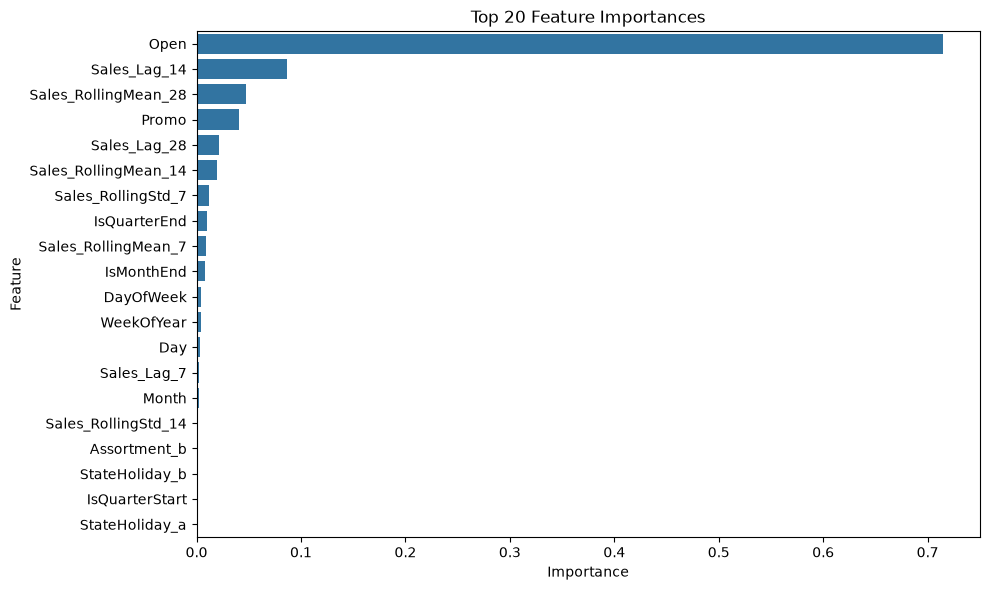

In [21]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances")
plt.tight_layout()

plt.savefig("feature_importance.png")

plt.show()

In [22]:
mlflow.log_artifact("feature_importance.png")

In [23]:
mlflow.end_run()

In [24]:
mlflow.active_run()

# RUN 2 - Open stores only


In [25]:
open_df = df[df["Open"] == 1].copy()

print(open_df.shape)

(818845, 42)


In [26]:
train_df = open_df[open_df["Date"] <= "2015-05-31"]
valid_df = open_df[open_df["Date"] >= "2015-06-01"]

print(train_df.shape)
print(valid_df.shape)

(760234, 42)
(58611, 42)


In [27]:
drop_cols = [
    "Sales",
    "Customers",
    "Open",
    "Date"
]

X_train = train_df.drop(columns=drop_cols)
y_train = train_df["Sales"]

X_valid = valid_df.drop(columns=drop_cols)
y_valid = valid_df["Sales"]

In [28]:
with mlflow.start_run(run_name="XGBoost_Open_Stores"):
    
    print("Run Started")

Run Started


In [29]:
from xgboost import XGBRegressor

xgb_open = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=8,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)


In [30]:
with mlflow.start_run(run_name="XGBoost_Open_Stores"):

    xgb_open = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1
    )

    # Train
    xgb_open.fit(X_train, y_train)

    # Predict
    preds = xgb_open.predict(X_valid)

In [31]:
mae = mean_absolute_error(y_valid, preds)

rmse = np.sqrt(
    mean_squared_error(y_valid, preds)
)

r2 = r2_score(y_valid, preds)

print(f"MAE : {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2  : {r2:.4f}")

MAE : 621.49
RMSE: 881.53
R2  : 0.9197


In [32]:
mlflow.log_param("n_estimators", 300)
mlflow.log_param("max_depth", 8)
mlflow.log_param("learning_rate", 0.05)
mlflow.log_param("subsample", 0.8)
mlflow.log_param("colsample_bytree", 0.8)   


0.8

In [33]:
mlflow.log_metric("mae", mae)
mlflow.log_metric("rmse", rmse)
mlflow.log_metric("r2", r2)

In [34]:
mlflow.set_tag(
    "dataset_type",
    "open_stores"
)

mlflow.set_tag(
    "model_family",
    "xgboost"
)

mlflow.set_tag(
    "business_use_case",
    "open_store_forecasting"
)

In [35]:
mlflow.xgboost.log_model(
    xgb_open,
    name="xgboost_open_store_model"
)

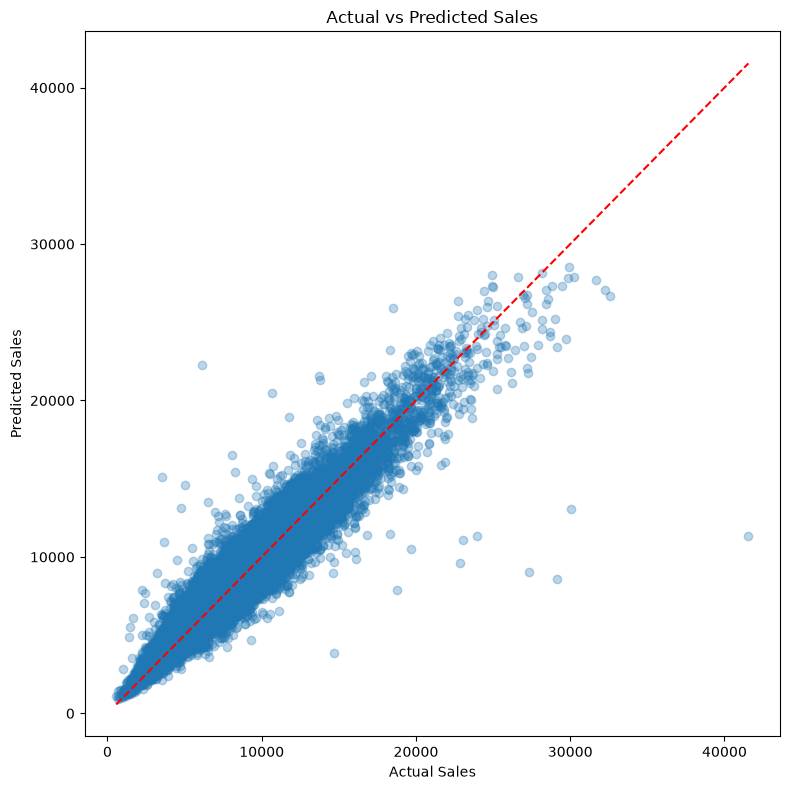

In [36]:
plt.figure(figsize=(8,8))

plt.scatter(
    y_valid,
    preds,
    alpha=0.3
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")

plt.plot(
    [y_valid.min(), y_valid.max()],
    [y_valid.min(), y_valid.max()],
    "r--"
)

plt.tight_layout()

plt.savefig("actual_vs_predicted_open.png")

plt.show()

In [37]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": xgb_open.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("Importance", ascending=False)
    .head(20)
)

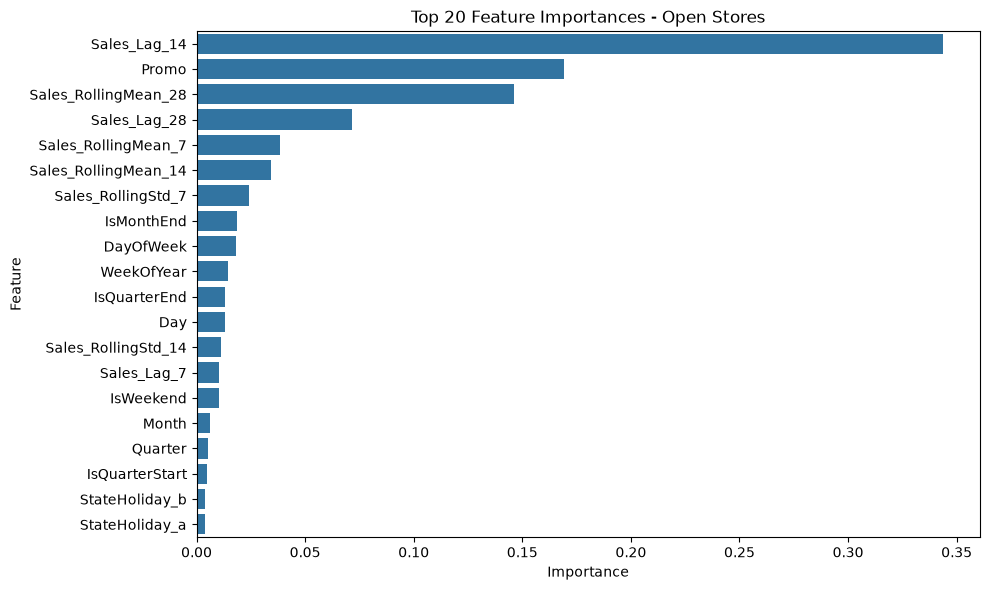

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Top 20 Feature Importances - Open Stores")
plt.tight_layout()

plt.savefig("feature_importance_open.png")

plt.show()

In [39]:
mlflow.log_artifact("feature_importance_open.png")

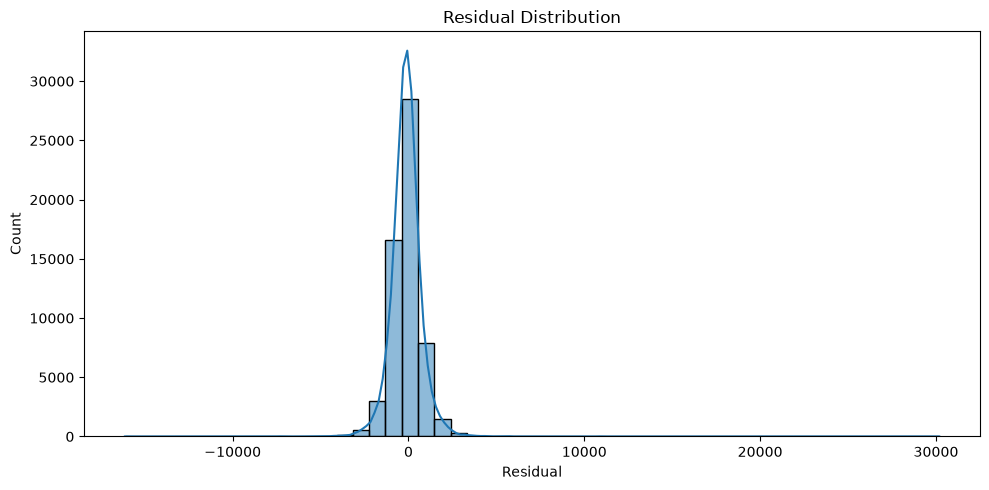

In [40]:
#residual plot- shows where model is making mistakes.
#  If the residuals are randomly distributed around zero, it indicates that the model is performing well.
#  If there is a pattern in the residuals, it suggests that the model is not capturing some aspect of the data.
residuals = y_valid - preds

plt.figure(figsize=(10,5))

sns.histplot(
    residuals,
    bins=50,
    kde=True
)

plt.title("Residual Distribution")
plt.xlabel("Residual")

plt.tight_layout()

plt.savefig("residual_distribution_open.png")

plt.show()

In [41]:
mlflow.log_artifact("residual_distribution_open.png")

In [42]:
if mlflow.active_run():
    mlflow.end_run()

In [43]:
print(mlflow.active_run())

None


# RUN 3 - Two way prediction using xgboost

In [44]:
with mlflow.start_run(run_name="Two_Stage_XGBoost"):
    print("Run Started")

Run Started


In [45]:
mlflow.log_param("pipeline_type", "two_stage")

mlflow.log_param("model", "XGBoost")

mlflow.log_param("n_estimators", 300)
mlflow.log_param("learning_rate", 0.05)
mlflow.log_param("max_depth", 8)
mlflow.log_param("subsample", 0.8)
mlflow.log_param("colsample_bytree", 0.8)

0.8

In [46]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

exp = client.get_experiment_by_name("Two_Stage_XGBoost")

client.delete_experiment(exp.experiment_id)

AttributeError: 'NoneType' object has no attribute 'experiment_id'

In [47]:
from mlflow.tracking import MlflowClient

client = MlflowClient()

for exp in client.search_experiments():
    print(exp.experiment_id, exp.name)

1 Rossmann_Demand_Forecasting
0 Default


In [48]:
if mlflow.active_run():
    mlflow.end_run()